In [1]:
!pip install pulp

   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
    --------------------------------------- 0.3/16.4 MB ? eta -:--:--
   -- ------------------------------------- 1.0/16.4 MB 4.0 MB/s eta 0:00:04
   ---- ----------------------------------- 1.8/16.4 MB 4.2 MB/s eta 0:00:04
   ------- -------------------------------- 3.1/16.4 MB 4.4 MB/s eta 0:00:04
   --------- ------------------------------ 3.9/16.4 MB 4.3 MB/s eta 0:00:03
   ----------- ---------------------------- 4.7/16.4 MB 4.3 MB/s eta 0:00:03
   -------------- ------------------------- 5.8/16.4 MB 4.4 MB/s eta 0:00:03
   --------------- ------------------------ 6.6/16.4 MB 4.4 MB/s eta 0:00:03
   ------------------ --------------------- 7.6/16.4 MB 4.4 MB/s eta 0:00:02
   --------------------- ------------------ 8.7/16.4 MB 4.4 MB/s eta 0:00:02
   ----------------------- ---------------- 9.7/16.4 MB 4.5 MB/s eta 0:00:02
   -------------------------- ------------- 10.7/16.4 MB 4.5 MB/s eta 0:00:02
   ---------

In [2]:
import pulp
print(pulp.__version__)

3.3.0


In [3]:
# Time
T = range(24)

# Building load (kWh)
load = [20, 18, 17, 16, 16, 18, 25, 30, 35, 32, 30, 28,
        27, 26, 28, 32, 38, 42, 45, 40, 35, 30, 25, 22]

# Electricity price (€/kWh)
price = [0.12, 0.11, 0.10, 0.10, 0.10, 0.12, 0.15, 0.18, 0.20, 0.18, 0.16, 0.15,
         0.14, 0.14, 0.15, 0.18, 0.22, 0.25, 0.28, 0.26, 0.22, 0.18, 0.15, 0.13]

# Battery parameters
E_max = 100     # capacity
E_min = 0
P_ch_max = 30
P_dis_max = 30
E_init = 50     # initial SOC

In [4]:
import pulp

model = pulp.LpProblem("Battery_Optimization", pulp.LpMinimize)

In [5]:
g = pulp.LpVariable.dicts("grid", T, lowBound=0)
ch = pulp.LpVariable.dicts("charge", T, lowBound=0)
dis = pulp.LpVariable.dicts("discharge", T, lowBound=0)
E = pulp.LpVariable.dicts("energy", T, lowBound=E_min, upBound=E_max)

In [6]:
model += pulp.lpSum(price[t] * g[t] for t in T)

In [7]:
for t in T:
    model += g[t] + dis[t] == load[t] + ch[t]

In [8]:
for t in T:
    if t == 0:
        model += E[t] == E_init + ch[t] - dis[t]
    else:
        model += E[t] == E[t-1] + ch[t] - dis[t]

In [9]:
for t in T:
    model += ch[t] <= P_ch_max

In [10]:
for t in T:
    model += dis[t] <= P_dis_max

In [11]:
model.solve()

1

In [12]:
print("Status:", pulp.LpStatus[model.status])

total_cost = pulp.value(model.objective)
print("Total cost:", total_cost)

Status: Optimal
Total cost: 95.82000000000001


In [13]:
for t in T:
    print(f"Hour {t}: Grid={g[t].value():.2f}, Charge={ch[t].value():.2f}, Discharge={dis[t].value():.2f}, SOC={E[t].value():.2f}")

Hour 0: Grid=0.00, Charge=0.00, Discharge=20.00, SOC=30.00
Hour 1: Grid=0.00, Charge=0.00, Discharge=18.00, SOC=12.00
Hour 2: Grid=45.00, Charge=28.00, Discharge=0.00, SOC=40.00
Hour 3: Grid=46.00, Charge=30.00, Discharge=0.00, SOC=70.00
Hour 4: Grid=46.00, Charge=30.00, Discharge=0.00, SOC=100.00
Hour 5: Grid=18.00, Charge=0.00, Discharge=0.00, SOC=100.00
Hour 6: Grid=25.00, Charge=0.00, Discharge=0.00, SOC=100.00
Hour 7: Grid=0.00, Charge=0.00, Discharge=30.00, SOC=70.00
Hour 8: Grid=5.00, Charge=0.00, Discharge=30.00, SOC=40.00
Hour 9: Grid=2.00, Charge=0.00, Discharge=30.00, SOC=10.00
Hour 10: Grid=20.00, Charge=0.00, Discharge=10.00, SOC=0.00
Hour 11: Grid=38.00, Charge=10.00, Discharge=0.00, SOC=10.00
Hour 12: Grid=57.00, Charge=30.00, Discharge=0.00, SOC=40.00
Hour 13: Grid=56.00, Charge=30.00, Discharge=0.00, SOC=70.00
Hour 14: Grid=58.00, Charge=30.00, Discharge=0.00, SOC=100.00
Hour 15: Grid=32.00, Charge=0.00, Discharge=0.00, SOC=100.00
Hour 16: Grid=28.00, Charge=0.00, Disc

In [14]:
import matplotlib.pyplot as plt

In [15]:
grid_vals = [g[t].value() for t in T]
ch_vals = [ch[t].value() for t in T]
dis_vals = [dis[t].value() for t in T]
soc_vals = [E[t].value() for t in T]

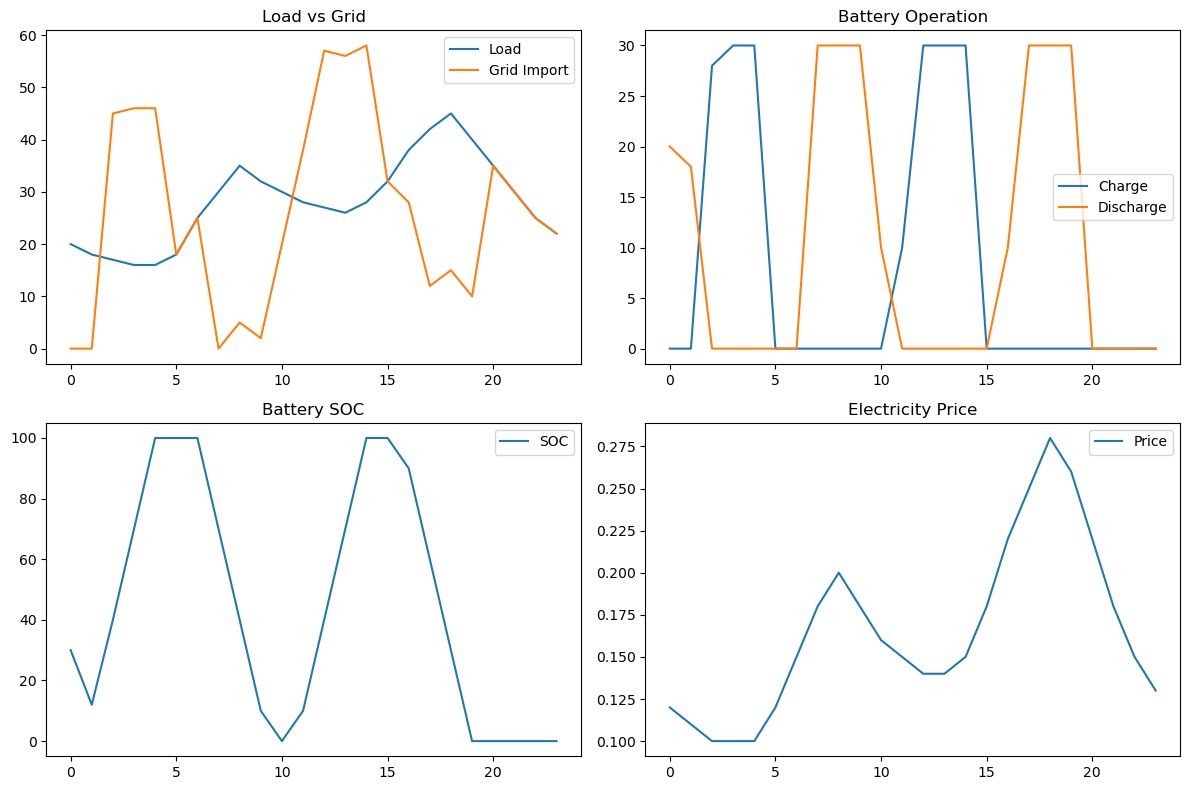

In [16]:
plt.figure(figsize=(12,8))

# Plot 1: Load vs Grid
plt.subplot(2,2,1)
plt.plot(T, load, label="Load")
plt.plot(T, grid_vals, label="Grid Import")
plt.title("Load vs Grid")
plt.legend()

# Plot 2: Charge / Discharge
plt.subplot(2,2,2)
plt.plot(T, ch_vals, label="Charge")
plt.plot(T, dis_vals, label="Discharge")
plt.title("Battery Operation")
plt.legend()

# Plot 3: SOC
plt.subplot(2,2,3)
plt.plot(T, soc_vals, label="SOC")
plt.title("Battery SOC")
plt.legend()

# Plot 4: Price
plt.subplot(2,2,4)
plt.plot(T, price, label="Price")
plt.title("Electricity Price")
plt.legend()

plt.tight_layout()
plt.show()